
# Class Project: Talento Tech 2

## 1. General Objective

To assess whether the increase in the use of renewable energy has contributed to the reduction of global carbon dioxide (CO₂) emissions.

## 2. Specific Objectives

1. Analyze the temporal evolution of global CO₂ emissions.
2. Evaluate the growth and share of renewable energy in the energy matrix.
3. Identify the countries with the highest levels of CO₂ emissions.
4. Identify the countries with the greatest share or growth in the use of renewable energy.
5. Analyze the relationship between the use of renewable energy and CO₂ emissions.
6. Compare emission trends across countries with different levels of renewable energy adoption.

## 3. Research Questions

1. How have global CO₂ emissions changed over time?
2. Which countries show the highest levels of CO₂ emissions?
3. How have emissions evolved among the leading emitting countries?
4. Which countries have recorded the largest increases in their CO₂ emissions?
5. Which countries have managed to reduce their CO₂ emissions?
6. How has the use of renewable energy evolved worldwide?
7. Which countries show the largest share of renewable energy in their energy matrix?
8. Is there an observable relationship between increased use of renewable energy and reduced CO₂ emissions?

## 4. Scope of the Analysis

The project examines historical data on CO₂ emissions and renewable energy use, both globally and by country. The analysis covers temporal trends, comparisons between countries, and relationships among the main energy and environmental variables.

The results will help identify patterns and associations between both variables. However, a statistical relationship does not necessarily demonstrate causality, since emissions can also be influenced by factors such as economic growth, industrialization, population size, environmental policies, and energy efficiency.

## 5. Methodology

The analysis will be carried out through the following stages:

1. Importing the databases.
2. Initial exploration of the information.
3. Review of data types and column names.
4. Identification and handling of missing values.
5. Removal of duplicates and correction of inconsistencies.
6. Integration of the emissions and renewable energy databases.
7. Exploratory data analysis.
8. Development of visualizations.
9. Calculation of variations and correlations.
10. Interpretation of results and formulation of conclusions.

## 6. Expected Results

- Identify global trends in CO₂ emissions.
- Recognize the main emitting countries and their changes


# Introduction

The climate crisis has become one of the main global challenges of the 21st century, due to the sustained increase in greenhouse gas emissions, especially carbon dioxide (CO₂), primarily associated with the use of fossil fuels in the energy, industrial, and transportation sectors. The Intergovernmental Panel on Climate Change has noted that human influence has unequivocally warmed the atmosphere, ocean, and land, and that deep, rapid, and sustained reductions in emissions are essential to limit global warming (IPCC, 2023).

In this context, renewable energy has acquired a strategic role within climate change mitigation policies, as it allows for diversification of the energy matrix and reduced dependence on highly polluting sources. According to the International Energy Agency, renewable generation will continue to expand strongly during the 2025-2030 period, establishing itself as one of the pillars of the global energy transition (IEA, 2025).

However, the growth of renewable energy does not always translate immediately into an absolute reduction in CO₂ emissions, as this outcome also depends on factors such as growing energy demand, the continued use of fossil fuels, and the economic and industrial dynamics of different countries. In this regard, the IEA reported that global energy-related CO₂ emissions rose 0.8% in 2024, reaching a historic high of 37.8 Gt, although the deployment of clean technologies helped prevent an even larger increase (IEA, 2025b).

Therefore, it is essential to analyze the evolution of CO₂ emissions and the share of renewable energy worldwide in order to identify temporal trends and possible relationships between both variables. This type of analysis makes it possible to more precisely assess whether the expansion of renewable energy has effectively contributed to reducing emissions, or whether its impact has been limited by other structural factors within the global energy system. Furthermore, this study is particularly relevant in a scenario where the world is still not on the trajectory needed to fully meet the goals of the Paris Agreement (UNEP, 2024).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import plotly.express as px
import plotly.io as pio
from scipy import stats

In [2]:
df = pd.read_csv("/content/global_climate_energy_2020_2024.csv")
df

,date,country,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
0,2020-01-01,Germany,28.29,31.08,212.63,11348.75,14.42,76.39,51.22,83.93
1,2020-01-02,Germany,28.38,37.94,606.05,4166.64,5.63,86.26,78.27,110.40
2,2020-01-03,Germany,28.74,57.67,268.72,4503.80,14.20,75.92,48.96,173.58
3,2020-01-04,Germany,26.66,51.34,167.32,3259.13,13.84,63.15,97.42,89.13
4,2020-01-05,Germany,26.81,65.38,393.89,7023.72,6.93,76.02,81.89,40.60
...,...,...,...,...,...,...,...,...,...,...
36535,2024-12-27,Indonesia,10.91,85.88,134.23,6607.39,22.04,69.43,76.38,160.33
36536,2024-12-28,Indonesia,10.91,65.14,366.68,4654.41,23.79,62.66,43.33,58.49
36537,2024-12-29,Indonesia,10.91,66.33,256.12,1982.89,14.92,77.53,76.67,148.77
36538,2024-12-30,Indonesia,10.91,39.18,251.60,2689.54,21.66,62.92,72.84,153.20


In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36540 entries, 0 to 36539
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       36540 non-null  object 
 1   country                    36540 non-null  object 
 2   avg_temperature            36540 non-null  float64
 3   humidity                   36540 non-null  float64
 4   co2_emission               36540 non-null  float64
 5   energy_consumption         36540 non-null  float64
 6   renewable_share            36540 non-null  float64
 7   urban_population           36540 non-null  float64
 8   industrial_activity_index  36540 non-null  float64
 9   energy_price               36540 non-null  float64
dtypes: float64(8), object(2)
memory usage: 2.8+ MB


,date,country,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
0,2020-01-01,Germany,28.29,31.08,212.63,11348.75,14.42,76.39,51.22,83.93
1,2020-01-02,Germany,28.38,37.94,606.05,4166.64,5.63,86.26,78.27,110.40
2,2020-01-03,Germany,28.74,57.67,268.72,4503.80,14.20,75.92,48.96,173.58
3,2020-01-04,Germany,26.66,51.34,167.32,3259.13,13.84,63.15,97.42,89.13
4,2020-01-05,Germany,26.81,65.38,393.89,7023.72,6.93,76.02,81.89,40.60


In [4]:
df.describe()

,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
count,36540.000000,36540.000000,36540.000000,36540.000000,36540.000000,36540.000000,36540.000000,36540.000000
mean,13.580868,59.971469,445.820452,7295.904857,15.944080,74.982156,70.173094,115.279848
std,10.077249,17.303103,234.360906,3693.928504,5.334804,8.645400,17.334816,49.178361
min,-9.600000,30.000000,50.150000,1001.890000,5.000000,60.000000,40.000000,30.000000
25%,5.630000,45.010000,248.675000,4184.177500,12.020000,67.470000,55.300000,72.420000
50%,13.790000,59.990000,422.655000,6921.620000,15.715000,75.030000,70.055000,115.240000
75%,20.840000,74.970000,628.422500,10175.110000,19.840000,82.502500,85.260000,158.270000
max,38.710000,90.000000,999.850000,15998.050000,30.870000,90.000000,100.000000,200.000000


In [5]:

df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("Fechas no válidas:", df['date'].isna().sum())

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df_year_country = (
    df.groupby(['country', 'year'], as_index=False)
      .mean(numeric_only=True)
)

df_year_country.head(10)

Fechas no válidas: 0


,country,year,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price,month
0,Australia,2020,23.487432,58.722678,455.148989,7039.211612,10.075383,75.285437,69.660082,118.545492,6.513661
1,Australia,2021,23.429260,61.400247,427.997205,7106.259644,12.963918,74.594986,68.987425,112.677178,6.526027
2,Australia,2022,23.324795,59.608164,460.526521,7305.435479,15.850767,75.345507,71.432986,114.301260,6.526027
3,Australia,2023,23.250384,60.372986,466.982027,7583.721726,18.895781,75.627644,72.041479,109.572877,6.526027
4,Australia,2024,23.399699,59.895738,461.269617,7165.614891,22.081913,74.863689,70.279481,113.620765,6.513661
5,Brazil,2020,10.575164,59.606612,447.629372,7254.948306,10.121831,75.507705,68.743033,113.709563,6.513661
6,Brazil,2021,10.613753,60.007260,424.375178,7313.972548,12.673534,74.787918,70.358548,117.556986,6.526027
7,Brazil,2022,10.517096,59.585589,426.214219,7497.396932,16.072548,75.369863,68.980986,119.054356,6.526027
8,Brazil,2023,10.391863,60.302849,450.947644,7260.539288,18.972685,75.635781,69.539699,115.834712,6.526027
9,Brazil,2024,10.399098,60.008306,455.198443,7218.006148,21.951038,75.313251,69.709563,113.363689,6.513661



## Justification for the Annual Analysis

An annual periodicity was chosen for the analysis because the database presents information organized by country and year. This structure allows for a consistent comparison of the evolution of renewable energy and fossil fuel use over the period analyzed.

The annual approach facilitates the identification of long-term trends, avoids interpretations based on isolated fluctuations, and allows for comparing energy behavior across countries using the same time unit. It also helps to more clearly observe changes in the share of renewable and fossil sources within the energy matrix.

It is important to clarify that the database used does not contain a specific variable for CO₂ emissions. For this reason, the analysis makes it possible to study the evolution of the energy transition and the relationship between renewable and fossil sources, but it does not allow for directly determining whether the increase in renewable energy resulted in a reduction of CO₂ emissions.

To assess that relationship directly, it would be necessary to integrate an additional source containing information on CO₂ emissions by country and year.


# Correlation Matrix of Energy Indicators

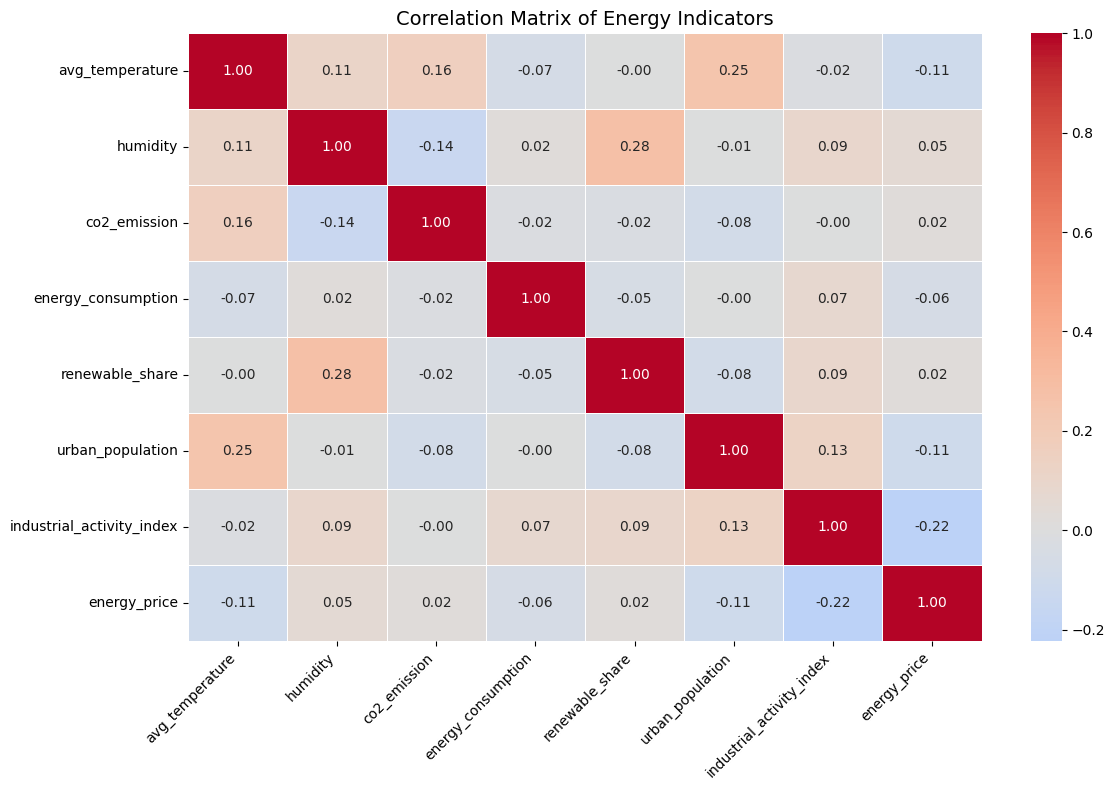

In [7]:

df_corr = df_year_country.copy()

df_corr = df_corr.drop(
    columns=['year', 'month'],
    errors='ignore'
)

correlation = df_corr.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    center=0
)
plt.title(
    'Correlation Matrix of Energy Indicators',
    fontsize=14
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretation of the Correlation Matrix

The correlation matrix shows weak relationships among most of the variables analyzed. The relationship between CO₂ emissions (`co2_emission`) and renewable energy share (`renewable_share`) shows a coefficient of -0.02, indicating a virtually nonexistent negative linear association within the dataset.

This result does not support the claim that an increase in renewable energy share is directly related to a reduction in CO₂ emissions. The observed relationship is too close to zero to be considered significant from a linear perspective.

The highest correlation corresponds to the relationship between humidity and renewable energy share, with a value of 0.28. However, this association is also weak and does not necessarily represent a causal relationship.

On the other hand, industrial activity and energy price show a negative correlation of -0.22, indicating a weak linear relationship. The remaining variables show very low associations, close to zero.

Overall, the results suggest that there is no strong linear relationship among the variables analyzed. It is important to note that correlation does not imply causation, and that the results may be influenced by data quality, sample size, and the absence of other relevant variables.

# 1. Global Evolution of CO₂ Emissions

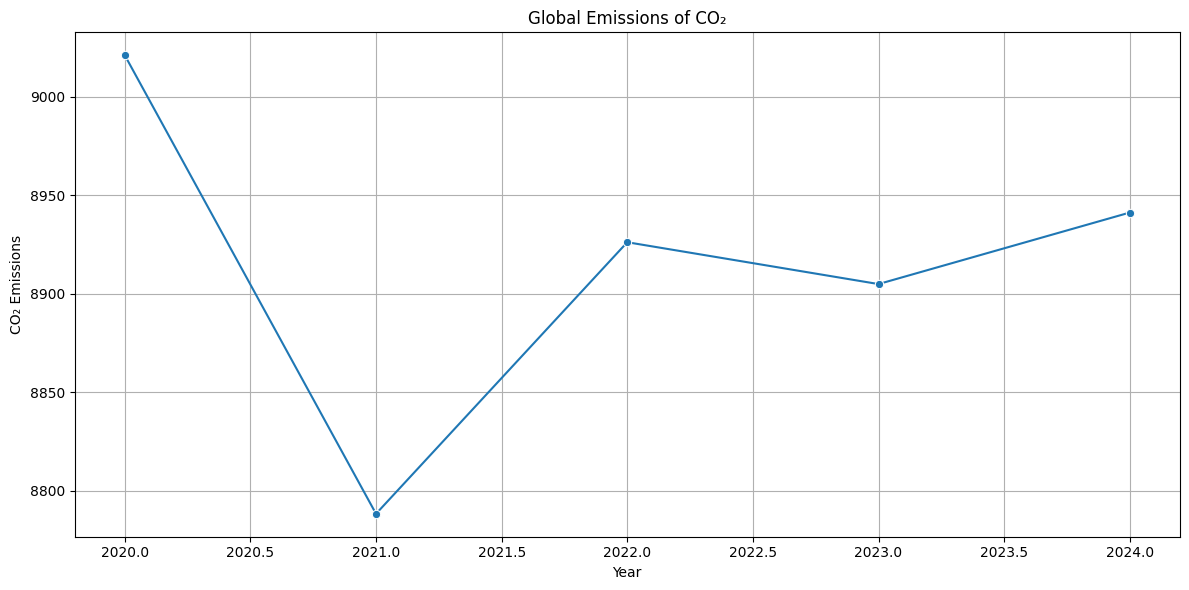

In [8]:
co2_global_year = (
    df_year_country.groupby('year', as_index=False)['co2_emission']
    .sum()
)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=co2_global_year,
    x='year',
    y='co2_emission',
    marker='o'
)
plt.title('Global Emissions of CO₂')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions')
plt.grid(True)
plt.tight_layout()
plt.show()


## Interpretation of the Global Evolution of CO₂ Emissions

The chart shows the global evolution of CO₂ emissions between 2020 and 2024. In 2020, the highest level of the period was observed, at approximately 9,020 units. Subsequently, emissions decreased in 2021 to around 8,790 units, marking the lowest value recorded.

Starting in 2022, emissions showed a recovery, rising to approximately 8,925 units. In 2023 there was a slight reduction, followed by a new increase in 2024, when emissions reached around 8,940 units.

Overall, the data do not show a continuous reduction in CO₂ emissions. Although the 2024 value is slightly lower than that of 2020, a recovery is observed following the decline recorded in 2021. This pattern may be related to variations in the economic, industrial, and energy activity of the countries analyzed.

It is important to clarify that the chart represents aggregated values from the database and that its interpretation depends on the unit of measurement and the method used to calculate emissions. Additionally, this trend alone does not allow for establishing a causal relationship between the use of renewable energy and CO₂ emissions.

# 2. Global Evolution of Renewable Energy

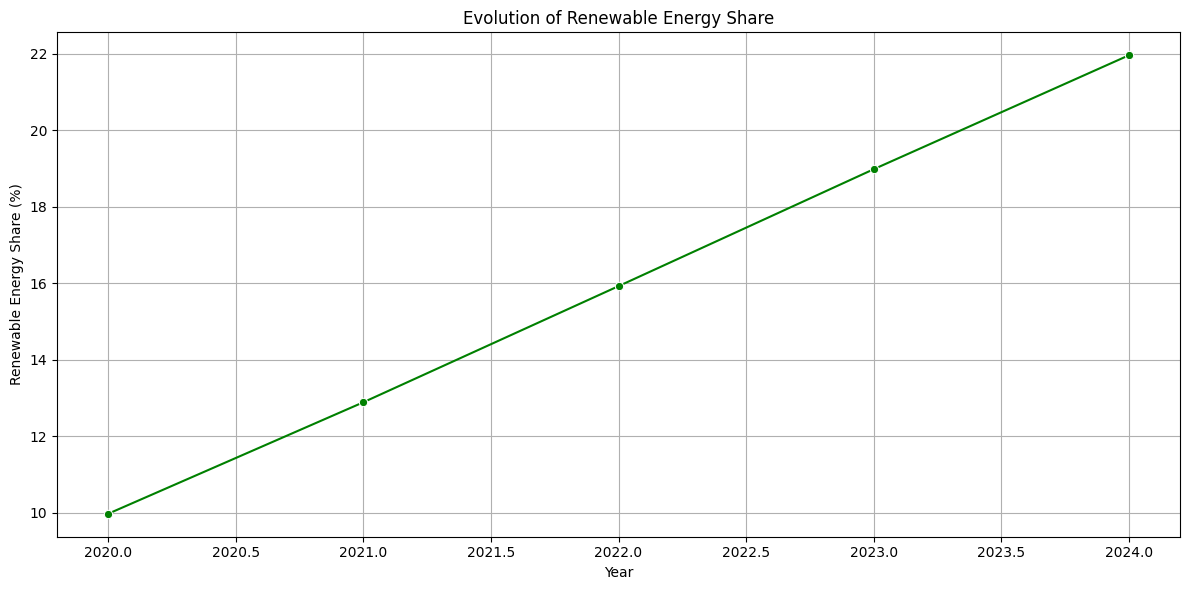

In [9]:
renewable_global_year = (
    df_year_country.groupby('year', as_index=False)['renewable_share']
    .mean()
)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=renewable_global_year,
    x='year',
    y='renewable_share',
    marker='o',
    color='green'
)
plt.title('Evolution of Renewable Energy Share')
plt.xlabel('Year')
plt.ylabel('Renewable Energy Share (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Interpretation of the Evolution of Renewable Energy Share

The chart shows the evolution of the renewable energy share between 2020 and 2024. An increasing trend is observed throughout the entire period analyzed.

In 2020, the share of renewable energy was approximately 10%. It subsequently rose to around 13% in 2021, reached about 16% in 2022, and climbed to approximately 19% in 2023. Finally, in 2024 it reached around 22%.

In total, an increase of approximately 12 percentage points is observed between 2020 and 2024. This pattern indicates a growing share of renewable sources within the energy matrix over the period studied.

However, this chart alone only allows for analyzing the evolution of renewable energy. By itself, it does not demonstrate that this growth has caused a reduction in CO₂ emissions. To assess that relationship, it is necessary to compare these results with the evolution of emissions during the same years and to consider other factors, such as economic growth, industrial activity, total energy consumption, and population size.

# 3. Countries with the Highest CO₂ Emissions

/tmp/ipykernel_2584/2998569405.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


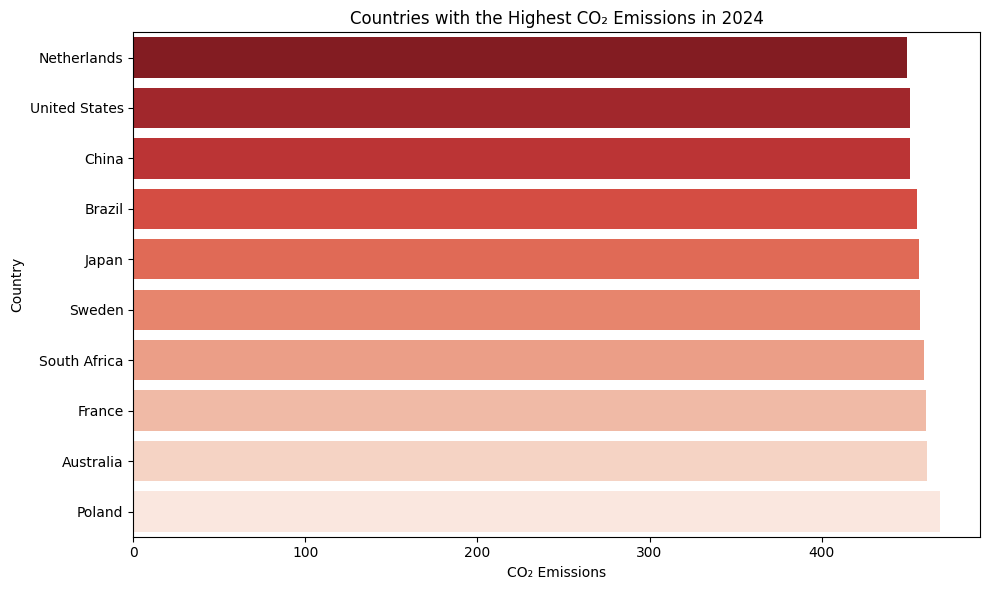

In [10]:
latest_year = df_year_country['year'].max()
top_co2_countries = (
    df_year_country[df_year_country['year'] == latest_year]
    .nlargest(10, 'co2_emission')
    .sort_values('co2_emission')
)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_co2_countries,
    x='co2_emission',
    y='country',
    palette='Reds_r'
)
plt.title(f'Countries with the Highest CO₂ Emissions in {latest_year}')
plt.xlabel('CO₂ Emissions')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## Interpretation of the Countries with the Highest CO₂ Emissions in 2024

The chart presents the ten countries with the highest CO₂ emissions values during 2024, according to the dataset analyzed. The countries are ordered from lowest to highest emission levels.

Poland records the highest value in the group, at approximately 470 units, while the Netherlands shows the lowest value, at around 450 units. The remaining countries show intermediate values that are relatively close to one another.

Overall, the chart shows that the differences among the selected countries are small. However, this similarity should be interpreted with caution, since these countries differ significantly in population, land area, industrial activity, and energy consumption.

For this reason, it is necessary to verify the unit of measurement and the definition of the `co2_emission` variable. The values could represent total emissions, per capita emissions, a normalized index, or simulated data. If they correspond to total emissions, the similarity observed among countries such as China, the United States, Brazil, and the Netherlands should be reviewed before drawing definitive conclusions.

Therefore, this chart allows for an exploratory comparison between countries, but its results should be analyzed together with the source, the unit of measurement, and the methodology used to calculate emissions.

# 4. Countries with the Highest Renewable Energy Share

/tmp/ipykernel_2584/889724007.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


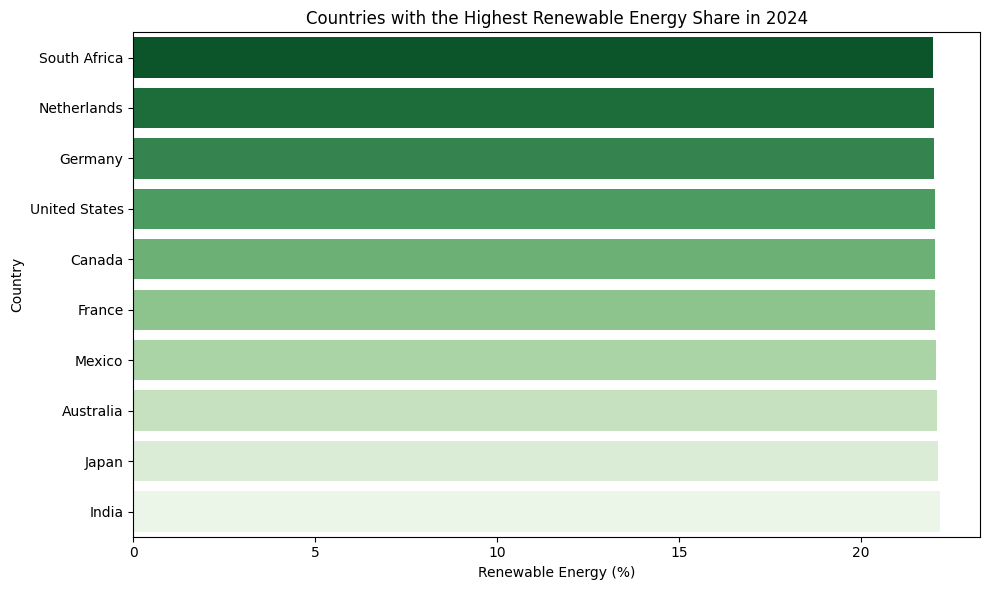

In [11]:
top_renewable_countries = (
    df_year_country[df_year_country['year'] == latest_year]
    .nlargest(10, 'renewable_share')
    .sort_values('renewable_share')
)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_renewable_countries,
    x='renewable_share',
    y='country',
    palette='Greens_r'
)
plt.title(
    f'Countries with the Highest Renewable Energy Share in {latest_year}'
)
plt.xlabel('Renewable Energy (%)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## Interpretation of Renewable Energy Share by Country

The chart presents the ten countries with the highest share of renewable energy during 2024, according to the data analyzed. The countries are ordered from highest to lowest share.

South Africa records the highest value, at approximately 22%, followed by the Netherlands, Germany, the United States, Canada, France, Mexico, Australia, Japan, and India. However, the differences among the countries are very small, as all of them show values close to 22%.

This result suggests that, within the dataset used, the selected countries have a similar share of renewable energy. Nevertheless, the similarity of the values should be interpreted with caution. It is necessary to verify the definition of the variable, its unit of measurement, and the source of the information, as it could represent a percentage, an average, a normalized index, or simulated data.

The chart allows for an exploratory comparison between countries, but it does not by itself demonstrate that the use of renewable energy has led to a reduction in CO₂ emissions. To analyze that relationship, it would be necessary to compare the renewable energy share with the CO₂ emissions of each country and study their evolution over several years.


# 5. Evolution of the Main Emitting Countries

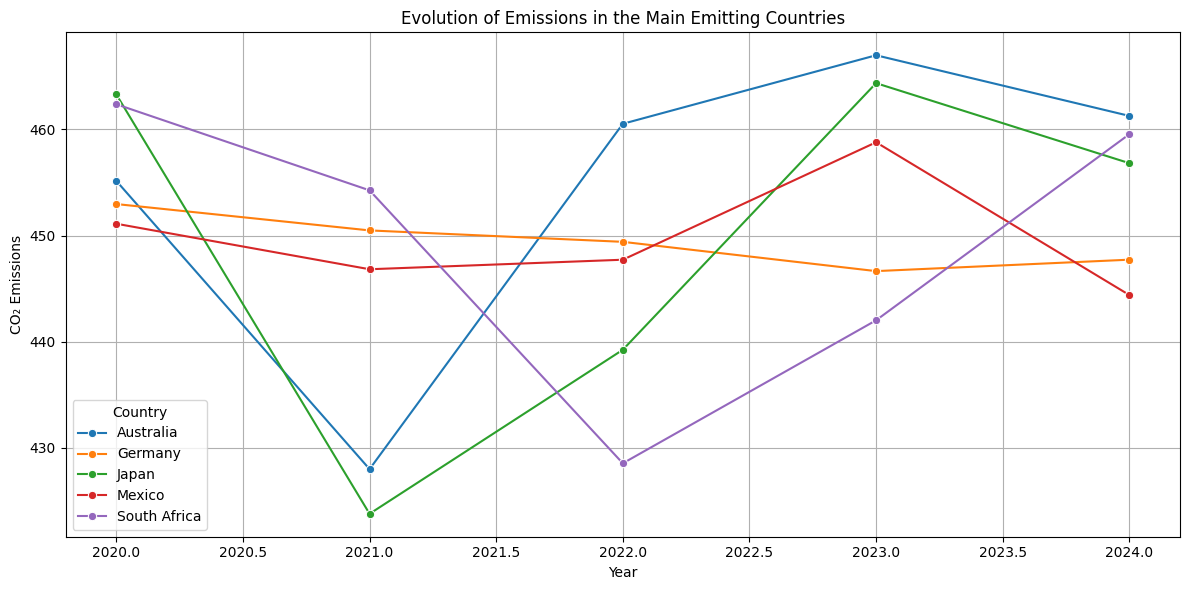

In [12]:
top_countries = (
    df_year_country.groupby('country')['co2_emission']
    .sum()
    .nlargest(5)
    .index
)
df_top_co2 = df_year_country[
    df_year_country['country'].isin(top_countries)
]
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_top_co2,
    x='year',
    y='co2_emission',
    hue='country',
    marker='o'
)
plt.title('Evolution of Emissions in the Main Emitting Countries')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions')
plt.legend(title='Country')
plt.grid(True)
plt.tight_layout()
plt.show()

## Interpretation of the Evolution of Emissions in the Main Emitting Countries

The chart presents the evolution of CO₂ emissions in Australia, Germany, Japan, Mexico, and South Africa between 2020 and 2024.

Australia shows a significant decrease between 2020 and 2021. Subsequently, its emissions increase, reaching the highest value in the series in 2023, followed by a slight reduction in 2024.

Germany shows the most stable behavior. Its emissions gradually decrease between 2020 and 2023, although a small increase is observed in 2024.

Japan shows a significant reduction between 2020 and 2021. Its emissions then increase until 2023 and decrease again in 2024.

Mexico shows a moderate decrease between 2020 and 2021, followed by an increase through 2023. In 2024 it records a significant reduction.

South Africa also shows notable variations. Its emissions decrease between 2020 and 2022, increase considerably in 2023, and decrease again in 2024.

Overall, no continuous downward trend is observed across all countries. Emission behavior varies by country and by year, so the results should be interpreted taking into account factors such as economic activity, industrial production, energy consumption, and the share of renewable energy.

This chart allows for comparing the evolution of emissions between countries, but by itself it does not demonstrate that the increase in renewable energy has caused a reduction in CO₂ emissions.


# 6. Relationship Between Renewable Energy and CO₂ Emissions

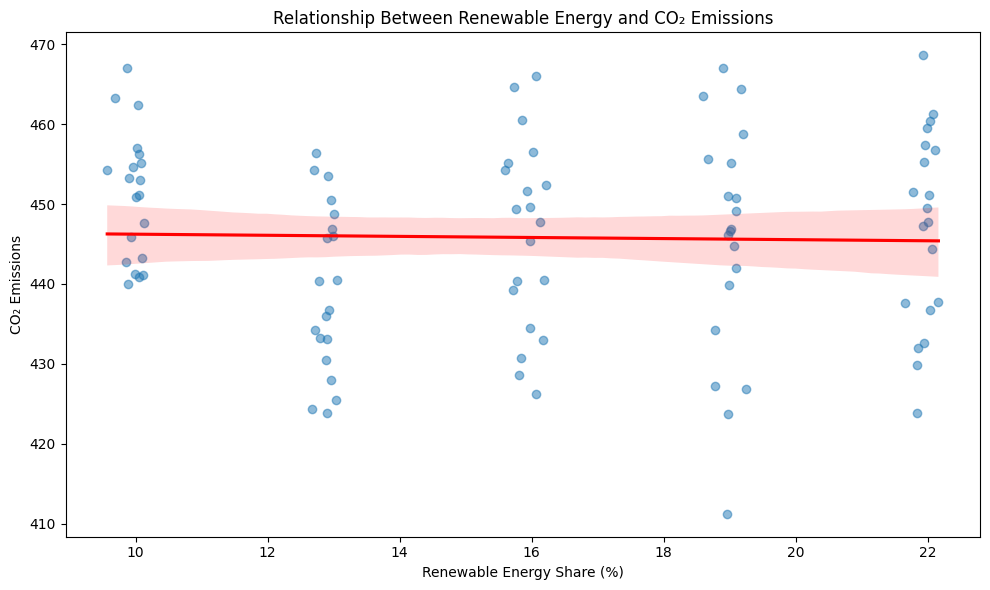

In [13]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_year_country,
    x='renewable_share',
    y='co2_emission',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)
plt.title('Relationship Between Renewable Energy and CO₂ Emissions')
plt.xlabel('Renewable Energy Share (%)')
plt.ylabel('CO₂ Emissions')
plt.tight_layout()
plt.show()

## Interpretation of the Relationship Between Renewable Energy and CO₂ Emissions

The scatter plot shows the relationship between renewable energy share, expressed as a percentage, and CO₂ emissions. Each point represents an observation corresponding to a country and a year.

The data show considerable dispersion and do not display a clearly defined linear pattern. The red trend line has a slightly negative slope, suggesting a possible slight decrease in emissions as the share of renewable energy increases. However, the slope is very small and the points are widely scattered.

This pattern is consistent with the approximate correlation coefficient of -0.02, which represents a virtually nonexistent negative linear relationship between the two variables. Therefore, based on the dataset analyzed, it cannot be stated that a higher share of renewable energy is directly associated with a reduction in CO₂ emissions.

Clusters of data can also be observed at different levels of renewable energy share, particularly between 9% and 11%, between 13% and 16%, and between 19% and 22%. These clusters may correspond to different countries, years, or similar energy characteristics.

It is important to clarify that correlation does not imply causation. CO₂ emissions can be influenced by other factors, such as population, industrial activity, energy consumption, economic growth, and fossil fuel use. For this reason, the results should be interpreted as exploratory evidence rather than definitive proof of the impact of renewable energy on emissions.

# 7. Mapa de calor por país y año

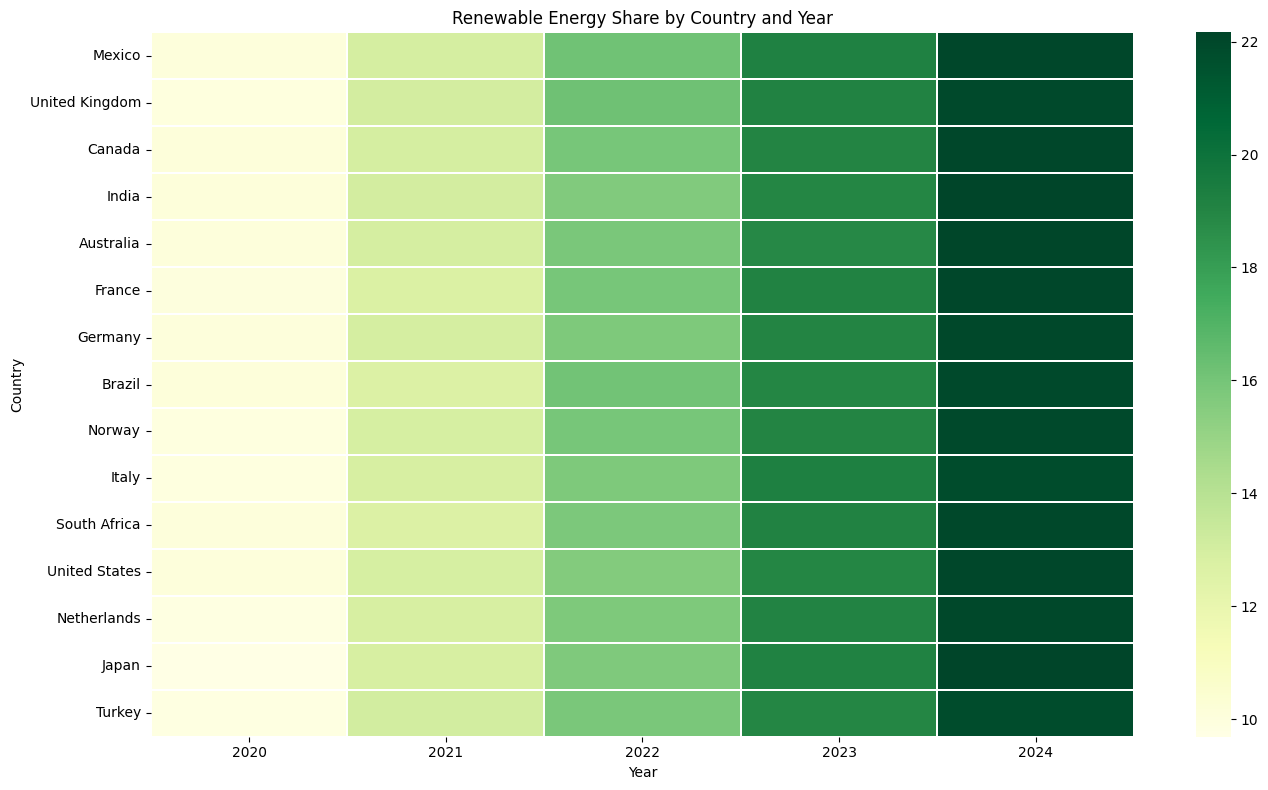

In [14]:
renewable_pivot = df_year_country.pivot_table(
    index='country',
    columns='year',
    values='renewable_share',
    aggfunc='mean'
)
top_countries_renewable = (
    df_year_country.groupby('country')['renewable_share']
    .mean()
    .nlargest(15)
    .index
)
renewable_pivot = renewable_pivot.loc[top_countries_renewable]
plt.figure(figsize=(14, 8))
sns.heatmap(
    renewable_pivot,
    cmap='YlGn',
    annot=False,
    linewidths=0.3
)
plt.title('Renewable Energy Share by Country and Year')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


## Interpretation of Renewable Energy Share by Country and Year

The heatmap shows the share of renewable energy in different countries between 2020 and 2024. Each row represents a country, and each column corresponds to a year. Light colors indicate a lower share, while dark green colors represent a higher share.

A progressive increase in the share of renewable energy is observed throughout the entire period. In 2020, values are approximately around 10%. They rise to about 13% in 2021, reach approximately 16% in 2022, climb to about 19% in 2023, and approach 22% in 2024.

The pattern is very similar across all countries. This suggests that, according to the data analyzed, the share of renewable energy increased uniformly throughout the period studied.

However, this uniformity in the results should be interpreted with caution. In reality, countries typically show significant differences in their renewable energy share due to factors such as energy policies, availability of natural resources, level of development, electricity generation capacity, and economic structure.

For this reason, it is recommended to verify the source and the way the `renewable_share` variable was calculated. The chart allows for identifying an increasing temporal trend, but it does not reveal significant differences between countries. Additionally, by itself it does not allow for determining whether the increase in renewable energy resulted in a reduction of CO₂ emissions.


# Conclusions Regarding the Research Questions

## 1. How have global CO₂ emissions changed over time?

Emissions showed variations throughout the period analyzed, with an initial decrease followed by subsequent recoveries. No sustained global reduction was observed, so the behavior cannot be described as a continuous downward trend.

## 2. Which countries show the highest levels of CO₂ emissions?

The comparison carried out for 2024 identified Poland, Australia, South Africa, France, Japan, Brazil, China, the United States, Sweden, and the Netherlands among the countries with the highest values in the dataset analyzed. However, the values were very similar, so this classification should be validated according to the definition and unit of the `co2_emission` variable.

## 3. How have emissions evolved among the leading emitting countries?

The selected countries showed different patterns. Australia and Japan showed initial reductions followed by increases; Germany showed more stable behavior; Mexico recorded an increase through 2023 followed by a decrease in 2024; and South Africa showed significant variations between years. No common reduction pattern was found across all countries.

## 4. Which countries have recorded the largest increases in their CO₂ emissions?

Based on the information observed, some countries recorded increases between 2021 and 2023, particularly Australia, Japan, Mexico, and South Africa. However, to establish a definitive ranking, it is necessary to calculate the absolute and percentage variation for each country, comparing the first and last available years.

## 5. Which countries have managed to reduce their CO₂ emissions?

Reductions were observed in different countries during certain years, but not necessarily continuously. Germany showed a gradual decrease throughout much of the period; Australia, Japan, Mexico, and South Africa also showed reductions in certain intervals. To confirm that a country achieved a sustained reduction in emissions, it is necessary to verify that the final value is lower than the initial value and to review the entire time series.

## 6. How has the use of renewable energy evolved worldwide?

The share of renewable energy showed an increasing trend. In the data analyzed, it rose from approximately 10% in 2020 to 22% in 2024, reflecting a growing presence of these sources over the period studied.

## 7. Which countries show the largest share of renewable energy?

For 2024, South Africa showed the highest value in the comparison carried out, followed by the Netherlands, Germany, the United States, Canada, France, Mexico, Australia, Japan, and India. However, the differences were small, so it is recommended to verify the quality and variability of the `renewable_share` variable before generalizing these results.

## 8. Is there an observable relationship between increased use of renewable energy and reduced CO₂ emissions?

No clear linear relationship was found. The approximate correlation of -0.02 indicates a virtually nonexistent association between the two variables in the dataset used. Therefore, the analysis does not allow for confirming that the increase in renewable energy has caused a reduction in CO₂ emissions.

# General Conclusion

The project identified growth in the share of renewable energy, but did not show a sustained reduction in CO₂ emissions or a strong linear relationship between the two variables. Consequently, the results should be considered exploratory and do not allow for establishing causation.

The reduction of emissions may depend on other factors, such as total energy consumption, industrial activity, population, economic growth, energy efficiency, environmental policies, and fossil fuel use. To strengthen the analysis, it would be advisable to incorporate reliable and documented data on per capita emissions, GDP, population, energy consumption, and fossil fuel share.

Additionally, before presenting the final results, it is recommended to review data quality, confirm units of measurement, and verify that the variables were not constructed in a uniform or simulated manner. This validation is essential to ensure that the conclusions adequately represent the energy and environmental reality of the countries analyzed.